**Reading the dataset & creating labels**

In [1]:
import os
from glob import glob
import pandas as pd


DATA_ROOT = "/kaggle/input/datasets/avinauty/main-dataset-mri1/Dataset"  # contains train/ and test/

CLASS_MAP = {"healthy": 0, "tumor": 1}
IMG_EXTS = ("*.png", "*.jpg", "*.jpeg", "*.bmp")

def collect_split(split_name: str) -> pd.DataFrame:
    rows = []
    split_dir = os.path.join(DATA_ROOT, split_name)

    for cls_name, cls_id in CLASS_MAP.items():
        cls_dir = os.path.join(split_dir, cls_name)

        files = []
        for ext in IMG_EXTS:
            files.extend(glob(os.path.join(cls_dir, ext)))

        for fp in files:
            rows.append({"path": fp, "label": cls_id})

    df = pd.DataFrame(rows).sample(frac=1.0, random_state=42).reset_index(drop=True)
    return df

train_df = collect_split("train")
test_df  = collect_split("test")

print("Train samples:", len(train_df))
print("Test samples :", len(test_df))

print("\nTrain label counts:")
print(train_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

print("\nSample rows:")
print(train_df.head(5))


Train samples: 2214
Test samples : 394

Train label counts:
label
1    1147
0    1067
Name: count, dtype: int64

Test label counts:
label
1    254
0    140
Name: count, dtype: int64

Sample rows:
                                                path  label
0  /kaggle/input/datasets/avinauty/main-dataset-m...      1
1  /kaggle/input/datasets/avinauty/main-dataset-m...      1
2  /kaggle/input/datasets/avinauty/main-dataset-m...      0
3  /kaggle/input/datasets/avinauty/main-dataset-m...      1
4  /kaggle/input/datasets/avinauty/main-dataset-m...      1


**Preprocess images (no augmentation yet)**

In [2]:
import tensorflow as tf
import numpy as np

IMG_SIZE = 224
BATCH_SIZE = 2
AUTOTUNE = tf.data.AUTOTUNE

def decode_image(path: tf.Tensor) -> tf.Tensor:
    """
    Reads an image from disk and decodes it into a float32 tensor in [0,1].
    Forces 3 channels for compatibility with ImageNet pretrained CNNs.
    """
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)  # -> [0,1]
    return img

def letterbox_resize(img: tf.Tensor, target: int = 224) -> tf.Tensor:
    """
    Aspect-preserving resize + padding to avoid stretching/squeezing.
    Output shape: (target, target, 3)
    """
    shape = tf.shape(img)
    h = tf.cast(shape[0], tf.float32)
    w = tf.cast(shape[1], tf.float32)

    # Scale to fit within target x target
    scale = tf.minimum(target / h, target / w)
    new_h = tf.cast(tf.round(h * scale), tf.int32)
    new_w = tf.cast(tf.round(w * scale), tf.int32)

    img = tf.image.resize(img, (new_h, new_w), method="bilinear")

    # Compute padding amounts
    pad_h = target - new_h
    pad_w = target - new_w
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    img = tf.pad(
        img,
        paddings=[[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]],
        constant_values=0.0
    )

    # Ensure static shape known to the model
    img = tf.ensure_shape(img, [target, target, 3])
    return img

def preprocess_fn(path: tf.Tensor, label: tf.Tensor):
    """
    Full preprocessing: decode -> letterbox resize.
    (No augmentation here; )
    """
    img = decode_image(path)
    img = letterbox_resize(img, IMG_SIZE)
    return img, label

def make_dataset(df, batch_size=2, shuffle=False):
    paths = df["path"].astype(str).values
    labels = df["label"].astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 2000), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(preprocess_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

# Build preprocessed datasets
train_ds_pre = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=False)
test_ds_pre  = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

# Quick sanity check: one batch
for images, labels in train_ds_pre.take(1):
    print("Batch images shape:", images.shape)   # (B, 224, 224, 3)
    print("Batch labels shape:", labels.shape)   # (B,)
    print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))


2026-05-05 00:01:57.296238: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777939317.518887      56 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777939317.584341      56 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777939318.090645      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777939318.090691      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777939318.090695      56 computation_placer.cc:177] computation placer alr

Batch images shape: (2, 224, 224, 3)
Batch labels shape: (2,)
Pixel range: 0.0 to 0.9752107858657837


**light augmentation module**

In [3]:
import tensorflow as tf

# Light augmentation (MRI-safe)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(factor=0.03),      # ~±10 degrees
    tf.keras.layers.RandomTranslation(0.05, 0.05),    # up to 5%
    tf.keras.layers.RandomZoom(0.05),                 # ±5%
    tf.keras.layers.RandomContrast(0.05),             # mild
], name="light_augment")


**augmentation to the TRAIN dataset only**

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

def apply_augment(img, label):
    # training=True makes randomness active
    img = augment(img, training=True)
    return img, label

train_ds_aug = train_ds_pre.map(apply_augment, num_parallel_calls=AUTOTUNE)
test_ds_aug  = test_ds_pre  # test stays unchanged


**Sanity check (shapes + ranges)**

In [5]:
for images, labels in train_ds_aug.take(1):
    print("Aug Train batch:", images.shape, labels.shape)
    print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

for images, labels in test_ds_aug.take(1):
    print("Test batch (no aug):", images.shape, labels.shape)


Aug Train batch: (2, 224, 224, 3) (2,)
Pixel range: 0.0 to 0.870535135269165
Test batch (no aug): (2, 224, 224, 3) (2,)


**3 CNN feature extractors (as embedding models, not classifiers)**

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre

# 1) Build extractor models (include_top=False + GAP)
def build_resnet_extractor(img_size=224):
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3))
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    return Model(base.input, x, name="ResNet50_Extractor")

def build_vgg_extractor(img_size=224):
    base = VGG16(weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3))
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    return Model(base.input, x, name="VGG16_Extractor")

def build_effnet_extractor(img_size=224):
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3))
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    return Model(base.input, x, name="EfficientNetB0_Extractor")

resnet_extractor = build_resnet_extractor()
vgg_extractor    = build_vgg_extractor()
eff_extractor    = build_effnet_extractor()

print(resnet_extractor.name, "output:", resnet_extractor.output_shape)
print(vgg_extractor.name,    "output:", vgg_extractor.output_shape)
print(eff_extractor.name,    "output:", eff_extractor.output_shape)

# 2) Sanity check on one batch (use your augmented train dataset)
for images, labels in train_ds_aug.take(1):
    # Important: each backbone expects its own preprocess_input
    r = resnet_extractor(resnet_pre(images), training=False)
    v = vgg_extractor(vgg_pre(images), training=False)
    e = eff_extractor(eff_pre(images), training=False)

    print("\nInput batch:", images.shape)
    print("ResNet feats:", r.shape)  # (B, 2048)
    print("VGG feats   :", v.shape)  # (B, 512)
    print("EffNet feats:", e.shape)  # (B, 1280)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50_Extractor output: (None, 2048)
VGG16_Extractor output: (None, 512)
EfficientNetB0_Extractor output: (None, 1280)


I0000 00:00:1777939350.229161      56 cuda_dnn.cc:529] Loaded cuDNN version 91002



Input batch: (2, 224, 224, 3)
ResNet feats: (2, 2048)
VGG feats   : (2, 512)
EffNet feats: (2, 1280)


**Full feature extraction + feature fusion**

In [7]:
import numpy as np
import tensorflow as tf

def extract_fused_features(ds, resnet_extractor, vgg_extractor, eff_extractor,
                          resnet_pre, vgg_pre, eff_pre, verbose=True):
    """
    Takes a tf.data.Dataset yielding (images, labels) and returns:
      X_fused: (N, 3840) numpy array
      y:      (N,) numpy array
    """
    fused_chunks = []
    y_chunks = []

    total_batches = 0
    for _ in ds:
        total_batches += 1

    # Iterate again (datasets are re-iterable)
    for bi, (images, labels) in enumerate(ds, start=1):
        # Apply backbone-specific preprocessing + extract embeddings
        r = resnet_extractor(resnet_pre(images), training=False)  # (B, 2048)
        v = vgg_extractor(vgg_pre(images), training=False)        # (B, 512)
        e = eff_extractor(eff_pre(images), training=False)        # (B, 1280)

        # Concatenate along feature dimension
        fused = tf.concat([r, v, e], axis=1)                      # (B, 3840)

        fused_chunks.append(fused.numpy())
        y_chunks.append(labels.numpy())

        if verbose and (bi % 20 == 0 or bi == total_batches):
            print(f"Processed batch {bi}/{total_batches}")

    X_fused = np.vstack(fused_chunks).astype(np.float32)
    y = np.concatenate(y_chunks).astype(np.int32)
    return X_fused, y

# --- Train (augmented) features ---
X_train_fused, y_train_out = extract_fused_features(
    train_ds_aug,
    resnet_extractor, vgg_extractor, eff_extractor,
    resnet_pre, vgg_pre, eff_pre,
    verbose=True
)

# --- Test (no augmentation) features ---
X_test_fused, y_test_out = extract_fused_features(
    test_ds_aug,
    resnet_extractor, vgg_extractor, eff_extractor,
    resnet_pre, vgg_pre, eff_pre,
    verbose=True
)

print("\nFinal shapes:")
print("X_train_fused:", X_train_fused.shape, "y_train:", y_train_out.shape)
print("X_test_fused :", X_test_fused.shape,  "y_test :", y_test_out.shape)

# Sanity check: feature dimension must be 3840
assert X_train_fused.shape[1] == 3840, "Train fused feature dim is not 3840!"
assert X_test_fused.shape[1] == 3840,  "Test fused feature dim is not 3840!"

# Optional: save to disk so you never recompute features
np.save("X_train_fused.npy", X_train_fused)
np.save("y_train.npy", y_train_out)
np.save("X_test_fused.npy", X_test_fused)
np.save("y_test.npy", y_test_out)

print("\nSaved: X_train_fused.npy, y_train.npy, X_test_fused.npy, y_test.npy")


Processed batch 20/1107
Processed batch 40/1107
Processed batch 60/1107
Processed batch 80/1107
Processed batch 100/1107
Processed batch 120/1107
Processed batch 140/1107
Processed batch 160/1107
Processed batch 180/1107
Processed batch 200/1107
Processed batch 220/1107
Processed batch 240/1107
Processed batch 260/1107
Processed batch 280/1107
Processed batch 300/1107
Processed batch 320/1107
Processed batch 340/1107
Processed batch 360/1107
Processed batch 380/1107
Processed batch 400/1107
Processed batch 420/1107
Processed batch 440/1107
Processed batch 460/1107
Processed batch 480/1107
Processed batch 500/1107
Processed batch 520/1107
Processed batch 540/1107
Processed batch 560/1107
Processed batch 580/1107
Processed batch 600/1107
Processed batch 620/1107
Processed batch 640/1107
Processed batch 660/1107
Processed batch 680/1107
Processed batch 700/1107
Processed batch 720/1107
Processed batch 740/1107
Processed batch 760/1107
Processed batch 780/1107
Processed batch 800/1107
Proc

**Load saved features**

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_train_fused = np.load("X_train_fused.npy")
y_train = np.load("y_train.npy")

X_test_fused = np.load("X_test_fused.npy")
y_test = np.load("y_test.npy")

print("Loaded shapes:")
print("X_train:", X_train_fused.shape)
print("X_test :", X_test_fused.shape)


Loaded shapes:
X_train: (2214, 3840)
X_test : (394, 3840)


**Fit scaler on training features**

In [9]:
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train_fused)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test_fused)


**Sanity check scaling**

In [10]:
print("Train mean (first 5 features):", X_train_scaled.mean(axis=0)[:5])
print("Train std  (first 5 features):", X_train_scaled.std(axis=0)[:5])

print("Test mean  (first 5 features):", X_test_scaled.mean(axis=0)[:5])
print("Test std   (first 5 features):", X_test_scaled.std(axis=0)[:5])


Train mean (first 5 features): [0.0000000e+00 0.0000000e+00 1.1328652e-07 2.7909726e-07 1.5937646e-08]
Train std  (first 5 features): [0.        0.        1.0000099 0.9999985 1.0000007]
Test mean  (first 5 features): [ 0.          0.         -0.0157001  -0.07362514  0.04831364]
Test std   (first 5 features): [0.0000000e+00 0.0000000e+00 6.4870018e-01 2.4586916e-07 1.1853650e+00]


In [11]:
np.save("X_train_scaled.npy", X_train_scaled)
np.save("X_test_scaled.npy", X_test_scaled)

print("Saved: X_train_scaled.npy, X_test_scaled.npy")


Saved: X_train_scaled.npy, X_test_scaled.npy


In [15]:
import numpy as np

# -------------------------
# Load scaled features
# -------------------------
X_train = np.load("X_train_scaled.npy").astype(np.float32)  # (2214, 3840)
X_test  = np.load("X_test_scaled.npy").astype(np.float32)   # (394, 3840)
y_train = np.load("y_train.npy").astype(np.float32)         # (2214,)

N_samples, D = X_train.shape
print("Loaded:", X_train.shape, X_test.shape, y_train.shape)

# -------------------------
# Utility: correlation
# Corr(X,Y) = cov(X,Y) / (stdX*stdY)
# We compute correlations using training data only.
# -------------------------
eps = 1e-12

# Standardize y for correlation computation (Q in the paper)
y = y_train.copy()
y = y - y.mean()
std_y = y.std() + eps
y = y / std_y  # now mean 0, std 1

# X_train is already standardized by StandardScaler (mean~0, std~1 per feature)
# but some features can be constant -> std=0 -> column is all zeros.
# That's OK; correlations will become ~0 safely.

def binarize_position(pos, threshold=0.5):
    """Convert continuous position vector to a binary mask."""
    return (pos >= threshold).astype(np.uint8)

def ensure_nonempty(mask, rng):
    """Ensure at least one feature is selected."""
    if mask.sum() == 0:
        mask[rng.integers(0, mask.size)] = 1
    return mask

def fitness_eq2(mask):
    """
    EXACT fitness from Eq. (2):

    Fitness(x) = [ (1/K^2) * sum_{i=1..K} sum_{j=1..K} |Corr(x_i, x_j)| ]
                 / [ sqrt(K) * ( 1 + (1/K) * sum_{k=1..K} |Corr(x_k, Q)| ) ]

    where x_i are the selected feature columns, Q is the label vector.
    """
    idx = np.flatnonzero(mask)
    K = idx.size
    if K == 0:
        return np.inf

    Xs = X_train[:, idx]  # (N_samples, K)

    # --- Corr(feature_k, Q) for each selected feature (absolute) ---
    # Since y is mean0 std1, corr(x, y) = cov(x,y)/(std_x*1)
    # But std_x is ~1 for standardized features; for constant columns it is 0 -> handle with eps.
    # Compute cov(x,y) = mean(x*y) because both are mean0 (approximately).
    # More exactly: cov = (x_centered·y_centered)/(N-1). Here y is centered; X is centered by scaler.
    # We'll compute using (N-1) for correctness.
    denom = float(N_samples - 1)
    # std_x per selected feature:
    std_x = Xs.std(axis=0) + eps
    cov_xy = (Xs * y[:, None]).sum(axis=0) / denom
    corr_xq = np.abs(cov_xy / std_x)  # since std_y = 1 after normalization

    # --- Corr among selected features (absolute) ---
    # Compute correlation matrix Corr(Xs_i, Xs_j) exactly:
    # Corr = Cov / (std_i * std_j)
    # Cov matrix = (Xs^T Xs)/(N-1) because Xs approx mean0
    cov_mat = (Xs.T @ Xs) / denom  # (K,K)
    denom_mat = (std_x[:, None] * std_x[None, :]) + eps
    corr_mat = cov_mat / denom_mat

    numerator = (np.abs(corr_mat).sum()) / (K * K)  # includes diagonal (|1| terms) as in Eq(2)
    denominator = (np.sqrt(K) * (1.0 + (corr_xq.mean())))  # 1 + (1/K) sum |Corr(xk,Q)|

    return float(numerator / (denominator + eps))

# -------------------------
# BHO (Steps 1–9) EXACT
# -------------------------
def bho_select_features(
    pop_size,          # N in the paper
    iterations,        # T in the paper
    threshold,        # for mapping position -> binary
    seed=42
):
    rng = np.random.default_rng(seed)

    # Step 1: Create starting population of binary strings (solution vectors) at random.
    # We'll store positions as float in {0,1} initially (still binary).
    #pop_pos = rng.integers(0, 2, size=(pop_size, D)).astype(np.float32)  # 0/1
    init_prob = 0.10
    pop_pos = (rng.random((pop_size, D)) < init_prob).astype(np.float32)
    pop_mask = np.zeros((pop_size, D), dtype=np.uint8)
    pop_fit = np.zeros(pop_size, dtype=np.float64)

    for i in range(pop_size):
        pop_mask[i] = ensure_nonempty(pop_pos[i].astype(np.uint8), rng)
        pop_pos[i] = pop_mask[i].astype(np.float32)
        # Step 2: Determine each solution vector’s fitness using Eq.(2).
        pop_fit[i] = fitness_eq2(pop_mask[i])

    # Step 3: Determine black hole with the lowest fitness.
    bh_idx = int(np.argmin(pop_fit))
    XBH = pop_pos[bh_idx].copy()
    BH_mask = pop_mask[bh_idx].copy()
    BH_fit = float(pop_fit[bh_idx])

    history = [BH_fit]

    for t in range(iterations):
        # Step 4: Adjust each solution’s location using Eq.(3)
        for i in range(pop_size):
            if i == bh_idx:
                continue

            # Eq.(3): Xi = Xi + rand * (XBH - Xi)
            rand_scalar = float(rng.random())  # rand in (0,1) (scalar, as written)
            pop_pos[i] = pop_pos[i] + rand_scalar * (XBH - pop_pos[i])

            # Convert updated position to binary string for fitness evaluation
            pop_mask[i] = binarize_position(pop_pos[i], threshold=threshold).astype(np.uint8)
            pop_mask[i] = ensure_nonempty(pop_mask[i], rng)
            pop_fit[i] = fitness_eq2(pop_mask[i])

        # Step 5: Calculate threshold distance R (event horizon) using Eq.(4)
        denom_sum = float(np.sum(pop_fit) + eps)
        R = BH_fit / denom_sum

        # Step 6: If any solution has lower fitness than BH, replace BH with it.
        new_bh_idx = int(np.argmin(pop_fit))
        if float(pop_fit[new_bh_idx]) < BH_fit:
            bh_idx = new_bh_idx
            XBH = pop_pos[bh_idx].copy()
            BH_mask = pop_mask[bh_idx].copy()
            BH_fit = float(pop_fit[bh_idx])

        # Step 7: Remove solutions within distance R from BH and replace with new random solution vectors.
        # Paper says "within threshold distance R from black hole" — distance in solution space.
        # We use Euclidean distance in the (continuous) position space.
        for i in range(pop_size):
            if i == bh_idx:
                continue
            dist = float(np.linalg.norm(pop_pos[i] - XBH))  # Euclidean distance
            if dist < R:
                # replace with randomly generated binary solution vector
                pop_pos[i] = rng.integers(0, 2, size=D).astype(np.float32)
                pop_mask[i] = ensure_nonempty(pop_pos[i].astype(np.uint8), rng)
                pop_pos[i] = pop_mask[i].astype(np.float32)
                pop_fit[i] = fitness_eq2(pop_mask[i])

        # Step 8: repeat until iterations reached
        history.append(BH_fit)

        if (t + 1) % 10 == 0 or (t + 1) == iterations:
            print(f"Iter {t+1:03d}/{iterations} | BH fitness={BH_fit:.6f} | selected K={int(BH_mask.sum())}")

    # Step 9: Return BH with lowest fitness
    selected_idx = np.flatnonzero(BH_mask)
    return BH_mask, selected_idx, np.array(history, dtype=np.float64)

# -------------------------
# Run BHO
# -------------------------
best_mask, selected_idx, bho_history = bho_select_features(
    pop_size=25,
    iterations=80,
    threshold=0.65,
    seed=42
)

print("\nBHO done.")
print("Selected K =", selected_idx.size, "out of", D)

# Apply to train/test (deliverables)
X_train_bho = X_train[:, selected_idx]
X_test_bho  = X_test[:, selected_idx]

print("X_train_bho:", X_train_bho.shape)
print("X_test_bho :", X_test_bho.shape)

# Save outputs
np.save("bho_best_mask.npy", best_mask)
np.save("bho_selected_idx.npy", selected_idx)
np.save("X_train_bho.npy", X_train_bho)
np.save("X_test_bho.npy", X_test_bho)
np.save("bho_history.npy", bho_history)

print("\nSaved bho_best_mask.npy, bho_selected_idx.npy, X_train_bho.npy, X_test_bho.npy, bho_history.npy")


Loaded: (2214, 3840) (394, 3840) (2214,)
Iter 010/80 | BH fitness=0.002249 | selected K=1973
Iter 020/80 | BH fitness=0.002235 | selected K=1905
Iter 030/80 | BH fitness=0.002204 | selected K=1911
Iter 040/80 | BH fitness=0.002202 | selected K=1952
Iter 050/80 | BH fitness=0.002202 | selected K=1952
Iter 060/80 | BH fitness=0.002202 | selected K=1952
Iter 070/80 | BH fitness=0.002191 | selected K=1923
Iter 080/80 | BH fitness=0.002191 | selected K=1923

BHO done.
Selected K = 1923 out of 3840
X_train_bho: (2214, 1923)
X_test_bho : (394, 1923)

Saved bho_best_mask.npy, bho_selected_idx.npy, X_train_bho.npy, X_test_bho.npy, bho_history.npy


**Opt-SGD Binary Classification + Metrics (Tumor vs Normal)**

X_train: (2214, 1923)
X_test : (394, 1923)
Selected Features: 1923
Epoch 001 | Loss: 0.5960 | Train Acc: 0.7638 | Grad Norm: 3.7279 | Bias: -0.0001
Epoch 002 | Loss: 0.4600 | Train Acc: 0.8234 | Grad Norm: 2.2292 | Bias: 0.0020
Epoch 003 | Loss: 0.3574 | Train Acc: 0.9038 | Grad Norm: 1.4969 | Bias: 0.0035
Epoch 004 | Loss: 0.3179 | Train Acc: 0.9128 | Grad Norm: 0.9721 | Bias: 0.0026
Epoch 005 | Loss: 0.2787 | Train Acc: 0.9192 | Grad Norm: 0.7864 | Bias: 0.0008
Epoch 006 | Loss: 0.2541 | Train Acc: 0.9232 | Grad Norm: 0.6313 | Bias: -0.0011
Epoch 007 | Loss: 0.2366 | Train Acc: 0.9277 | Grad Norm: 0.5351 | Bias: -0.0031
Epoch 008 | Loss: 0.2201 | Train Acc: 0.9300 | Grad Norm: 0.4680 | Bias: -0.0054
Epoch 009 | Loss: 0.2091 | Train Acc: 0.9332 | Grad Norm: 0.4098 | Bias: -0.0074
Epoch 010 | Loss: 0.2002 | Train Acc: 0.9359 | Grad Norm: 0.3709 | Bias: -0.0093
Epoch 011 | Loss: 0.1996 | Train Acc: 0.9359 | Grad Norm: 0.3420 | Bias: -0.0095
Epoch 012 | Loss: 0.1946 | Train Acc: 0.9395 |

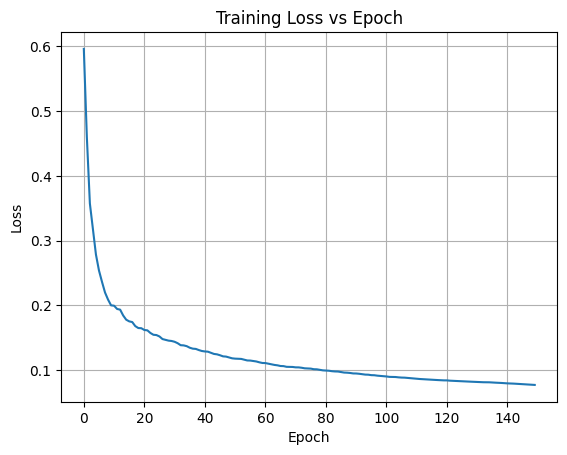

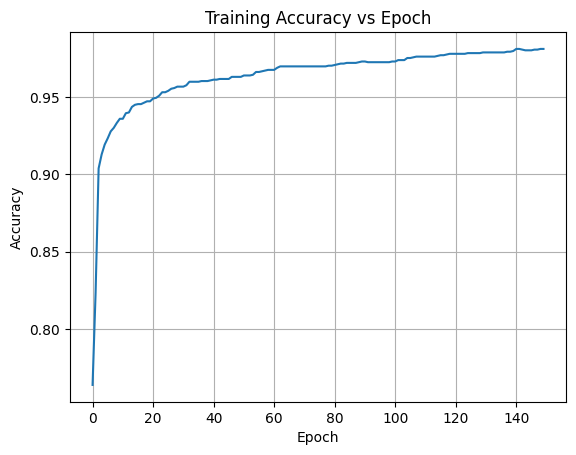


=== Test Performance (Tumor vs Normal) ===
Accuracy    : 0.9721
Precision   : 0.9919
Sensitivity : 0.9646
Specificity : 0.9857
F1-score    : 0.9780
ROC-AUC     : 0.9956
Final Bias  : -0.1626

Confusion Matrix:
[[np.int64(138), np.int64(2)], [np.int64(9), np.int64(245)]]
Confusion Matrix:
 [[138   2]
 [  9 245]]

Model, bias, and results saved.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# =========================================================
# 1) Load Data
# =========================================================

X_train = np.load("X_train_bho.npy")
X_test  = np.load("X_test_bho.npy")

y_train = np.load("y_train.npy").astype(int)
y_test  = np.load("y_test.npy").astype(int)

bho_selected_idx = np.load("bho_selected_idx.npy", allow_pickle=True)
bho_best_mask    = np.load("bho_best_mask.npy", allow_pickle=True)
bho_history      = np.load("bho_history.npy", allow_pickle=True)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Selected Features:", X_train.shape[1])

# =========================================================
# 2) Standardization
# =========================================================

eps = 1e-8
mu = X_train.mean(axis=0)
sd = X_train.std(axis=0) + eps

X_train_s = (X_train - mu) / sd
X_test_s  = (X_test - mu) / sd

# =========================================================
# 3) Opt-SGD Logistic Classifier WITH Bias
# =========================================================

class OptSGDLogistic:
    def __init__(self, lr, max_inner, epochs, l2, seed=42):
        self.lr = lr
        self.max_inner = max_inner
        self.epochs = epochs
        self.l2 = l2
        self.rng = np.random.default_rng(seed)

        self.loss_history = []
        self.acc_history = []
        self.grad_norm_history = []

    @staticmethod
    def sigmoid(z):
        z = np.clip(z, -30, 30)
        return 1.0 / (1.0 + np.exp(-z))

    def compute_loss(self, X, y, w, b):
        p = self.sigmoid(X @ w + b)
        eps = 1e-8

        loss = -np.mean(
            y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)
        )

        # L2 regularization is applied only to weights, not bias
        if self.l2 > 0:
            loss += 0.5 * self.l2 * np.sum(w ** 2)

        return loss

    def compute_accuracy(self, X, y, w, b):
        p = self.sigmoid(X @ w + b)
        preds = (p >= 0.5).astype(int)
        return np.mean(preds == y)

    def full_grad(self, X, y, w, b):
        n = X.shape[0]
        p = self.sigmoid(X @ w + b)
        error = p - y

        grad_w = (X.T @ error) / n
        grad_b = np.mean(error)

        if self.l2 > 0:
            grad_w += self.l2 * w

        return grad_w, grad_b

    def fit(self, X, y):
        n, d = X.shape

        # Initialize weights and bias
        self.w = np.zeros(d)
        self.b = 0.0

        for epoch in range(self.epochs):

            # ---- Full Gradient Anchor ----
            g_w, g_b = self.full_grad(X, y, self.w, self.b)

            # Temporary parameters
            y_w = self.w.copy()
            y_b = self.b

            # Random number of inner stochastic updates
            t_s = self.rng.integers(1, self.max_inner + 1)

            for _ in range(t_s):
                i = self.rng.integers(0, n)
                xi = X[i]
                yi = y[i]

                # ---- Gradient at temporary point ----
                p_cur = self.sigmoid(xi @ y_w + y_b)

                grad_cur_w = xi * (p_cur - yi)
                grad_cur_b = (p_cur - yi)

                if self.l2 > 0:
                    grad_cur_w += self.l2 * y_w

                # ---- Gradient at reference/original point ----
                p_ref = self.sigmoid(xi @ self.w + self.b)

                grad_ref_w = xi * (p_ref - yi)
                grad_ref_b = (p_ref - yi)

                if self.l2 > 0:
                    grad_ref_w += self.l2 * self.w

                # ---- Opt-SGD update ----
                y_w = y_w - self.lr * (g_w + grad_cur_w - grad_ref_w)
                y_b = y_b - self.lr * (g_b + grad_cur_b - grad_ref_b)

            # Commit temporary parameters
            self.w = y_w.copy()
            self.b = y_b

            # ---- Track metrics ----
            loss = self.compute_loss(X, y, self.w, self.b)
            acc = self.compute_accuracy(X, y, self.w, self.b)
            grad_norm = np.linalg.norm(g_w)

            self.loss_history.append(loss)
            self.acc_history.append(acc)
            self.grad_norm_history.append(grad_norm)

            print(
                f"Epoch {epoch+1:03d} | "
                f"Loss: {loss:.4f} | "
                f"Train Acc: {acc:.4f} | "
                f"Grad Norm: {grad_norm:.4f} | "
                f"Bias: {self.b:.4f}"
            )

        return self

    def predict_proba(self, X):
        return self.sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.30):
        return (self.predict_proba(X) >= threshold).astype(int)

# =========================================================
# 4) Train Model
# =========================================================

model = OptSGDLogistic(
    lr=0.005,
    max_inner=20,
    epochs=150,
    l2=1e-4,
    seed=42
)

model.fit(X_train_s, y_train)

# =========================================================
# 5) Plot Training Curves
# =========================================================

plt.figure()
plt.plot(model.loss_history)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(model.acc_history)
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# =========================================================
# 6) Evaluation on Test Set
# =========================================================

def confusion_matrix_binary(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return tn, fp, fn, tp

def safe_div(a, b):
    return a / b if b != 0 else 0.0

def roc_auc(y_true, y_score):
    y_true = y_true.astype(int)
    pos = y_score[y_true == 1]
    neg = y_score[y_true == 0]

    if len(pos) == 0 or len(neg) == 0:
        return np.nan

    scores = np.concatenate([pos, neg])
    labels = np.concatenate([np.ones_like(pos), np.zeros_like(neg)])

    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(scores) + 1)

    sum_ranks_pos = ranks[labels == 1].sum()
    n_pos = len(pos)
    n_neg = len(neg)

    auc = (sum_ranks_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return float(auc)

y_prob = model.predict_proba(X_test_s)
y_pred = model.predict(X_test_s, threshold=0.30)

tn, fp, fn, tp = confusion_matrix_binary(y_test, y_pred)

accuracy    = safe_div(tp + tn, tp + tn + fp + fn)
precision   = safe_div(tp, tp + fp)
recall      = safe_div(tp, tp + fn)
specificity = safe_div(tn, tn + fp)
f1          = safe_div(2 * precision * recall, precision + recall)
auc         = roc_auc(y_test, y_prob)

print("\n=== Test Performance (Tumor vs Normal) ===")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Sensitivity : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-score    : {f1:.4f}")
print(f"ROC-AUC     : {auc:.4f}")
print(f"Final Bias  : {model.b:.4f}")

print("\nConfusion Matrix:")
print([[tn, fp],
       [fn, tp]])

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# =========================================================
# 7) Save Outputs
# =========================================================

np.save("opt_sgd_weights.npy", model.w)
np.save("opt_sgd_bias.npy", np.array([model.b]))

np.save("opt_sgd_results.npy", {
    "model_name": "BHO + OPT-SGD",
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "specificity": specificity,
    "f1": f1,
    "auc": auc,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
    "bias": float(model.b),
    "loss_history": model.loss_history,
    "acc_history": model.acc_history,
    "grad_norm_history": model.grad_norm_history
}, allow_pickle=True)

print("\nModel, bias, and results saved.")